# ❤️ Week 4 – Heart Disease Prediction

### SkillNexis Machine Learning & AI Internship

---

## Objectives

In this notebook, we will:

- Load and explore the Heart Disease dataset
- Perform data preprocessing
- Build a Logistic Regression model
- Evaluate the model using multiple metrics
- Perform Cross Validation
- Optimize the model using GridSearchCV
- Save and Load the trained model
- Predict Heart Disease for new patients

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import joblib

## Load Dataset

In [39]:
heart_df = pd.read_csv("Heart.csv")

print("Heart Dataset Loaded Successfully!")

Heart Dataset Loaded Successfully!


In [40]:
heart_df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [41]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [42]:
heart_df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [43]:
heart_df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


## Data Cleaning

In [44]:
numeric_columns = heart_df.select_dtypes(include=["float64","int64"]).columns

for column in numeric_columns:
    heart_df[column].fillna(heart_df[column].median(), inplace=True)

/tmp/ipykernel_3254/2924140842.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  heart_df[column].fillna(heart_df[column].median(), inplace=True)


In [45]:
categorical_columns = heart_df.select_dtypes(include="object").columns

for column in categorical_columns:
    heart_df[column].fillna(heart_df[column].mode()[0], inplace=True)

/tmp/ipykernel_3254/4076981456.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  heart_df[column].fillna(heart_df[column].mode()[0], inplace=True)
/tmp/ipykernel_3254/4076981456.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heart_df[column].fillna(heart_df[column].mode()[0], inplace=True)


In [46]:
heart_df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


## Encode Categorical Features

In [47]:
label_encoder = LabelEncoder()

categorical_columns = heart_df.select_dtypes(include="object").columns

for column in categorical_columns:
    heart_df[column] = label_encoder.fit_transform(heart_df[column])

heart_df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,0,3,145.0,233.0,True,0,150.0,False,2.3,0,0.0,0,0
1,2,67,1,0,0,160.0,286.0,False,0,108.0,True,1.5,1,3.0,1,2
2,3,67,1,0,0,120.0,229.0,False,0,129.0,True,2.6,1,2.0,2,1
3,4,37,1,0,2,130.0,250.0,False,1,187.0,False,3.5,0,0.0,1,0
4,5,41,0,0,1,130.0,204.0,False,0,172.0,False,1.4,2,0.0,1,0


## Convert Target into Binary Classification

The original dataset contains five classes:

- 0 → No Heart Disease
- 1–4 → Heart Disease

We convert it into a binary classification problem.

In [48]:
heart_df["num"] = heart_df["num"].apply(lambda x: 0 if x==0 else 1)

In [49]:
heart_df["num"].value_counts()

,count
num,
1,509
0,411


## Prepare Features and Target

In [50]:
X = heart_df.drop("num", axis=1)

y = heart_df["num"]

## Train-Test Split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Feature Scaling

In [52]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Train Logistic Regression Model

In [53]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [54]:
predictions = model.predict(X_test)

## Model Accuracy

In [55]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy :", accuracy)

Accuracy : 0.8641304347826086


## Classification Report

In [56]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84        82
           1       0.85      0.91      0.88       102

    accuracy                           0.86       184
   macro avg       0.87      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184



## Confusion Matrix

The confusion matrix helps visualize the model's prediction performance by comparing actual and predicted classes.

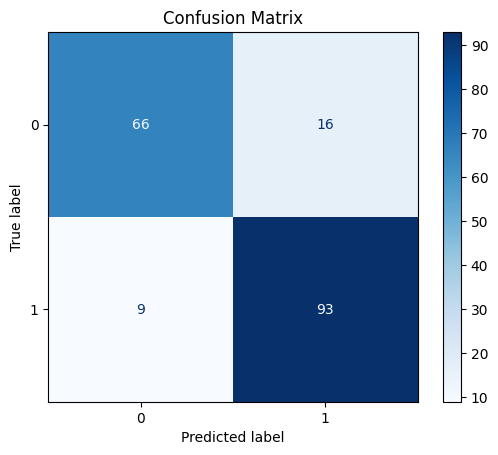

In [57]:
cm = confusion_matrix(y_test, predictions)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

## ROC Curve

The ROC Curve illustrates the model's ability to distinguish between patients with and without heart disease.

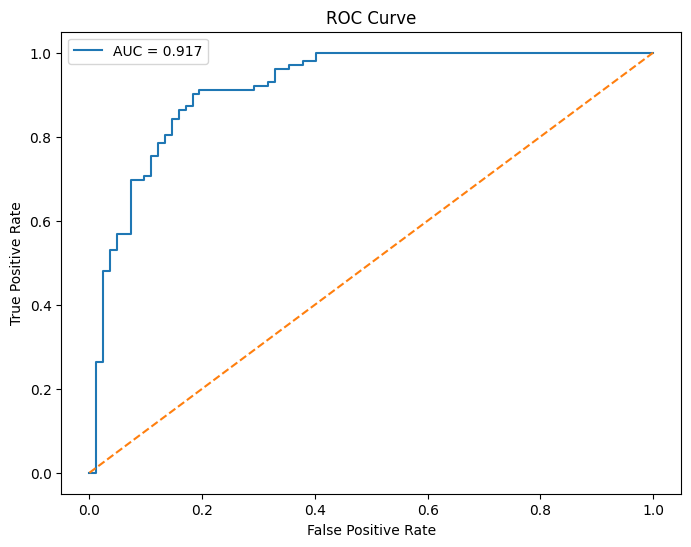

In [58]:
probabilities = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, probabilities)

roc_auc = roc_auc_score(y_test, probabilities)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Cross Validation

Cross Validation evaluates the model on different subsets of the dataset to provide a more reliable estimate of performance.

In [59]:
cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    scaler.transform(X),
    y,
    cv=5
)

print("Cross Validation Scores:")

print(cv_scores)

print("Average CV Accuracy:", cv_scores.mean())

Cross Validation Scores:
[0.58695652 0.74456522 0.89130435 0.85326087 0.60326087]
Average CV Accuracy: 0.7358695652173912


## Hyperparameter Tuning using GridSearchCV

GridSearchCV searches for the best combination of hyperparameters to improve model performance.

In [60]:
parameters = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    parameters,
    cv=5
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'lbfgs']})

In [61]:
print("Best Parameters:")

print(grid.best_params_)

print()

print("Best Cross Validation Score:")

print(grid.best_score_)

Best Parameters:
{'C': 0.01, 'solver': 'liblinear'}

Best Cross Validation Score:
0.8219893362750506


## Best Model Performance

In [62]:
best_model = grid.best_estimator_

best_predictions = best_model.predict(X_test)

print("Accuracy of Best Model:")

print(accuracy_score(y_test, best_predictions))

Accuracy of Best Model:
0.842391304347826


## Save the Trained Model

The trained model is saved using Joblib so it can be reused later without retraining.

In [63]:
joblib.dump(best_model, "heart_disease_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


## Load the Saved Model

In [64]:
loaded_model = joblib.load("heart_disease_model.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


## Predicting Heart Disease for a New Patient

Now we will use the saved model to predict whether a new patient is likely to have heart disease.

In [65]:
new_patient_df = pd.DataFrame(
    [[
        1,
        63,
        1,
        0,
        3,
        145,
        233,
        1,
        0,
        150,
        0,
        2.3,
        1,
        0,
        2
    ]],
    columns=X.columns
)

new_patient_scaled = scaler.transform(new_patient_df)

prediction = loaded_model.predict(new_patient_scaled)

if prediction[0] == 1:
    print("❤️ Heart Disease Detected")
else:
    print("💚 No Heart Disease Detected")

💚 No Heart Disease Detected


In [66]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

feature_importance


,Feature,Coefficient
10,exang,0.332326
11,oldpeak,0.308833
4,cp,-0.290578
13,ca,0.287879
0,id,0.286529
2,sex,0.257828
9,thalch,-0.208768
1,age,0.183898
6,chol,-0.178584
14,thal,0.154564


## Feature Importance Visualization

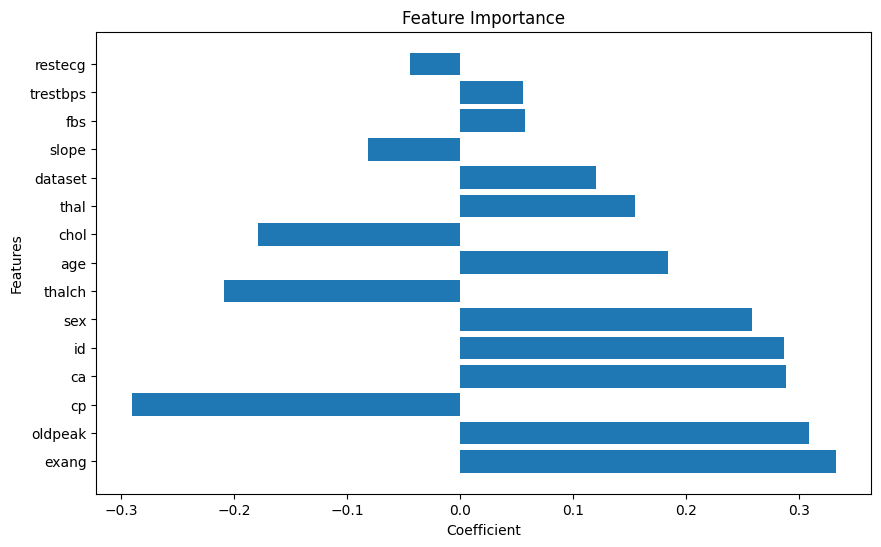

In [67]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.title("Feature Importance")

plt.show()

## Conclusion

In this project, a Heart Disease Prediction model was developed using Logistic Regression.

The dataset was preprocessed by handling missing values, encoding categorical variables, scaling numerical features, and converting the target into binary classes.

The model was evaluated using:
- Accuracy
- Classification Report
- Confusion Matrix
- ROC Curve
- Cross Validation
- GridSearchCV

Finally, the trained model was saved using Joblib and successfully used to predict heart disease for a new patient.

This project demonstrates a complete machine learning workflow and fulfills the requirements of the Learning & AI Internship Week 4 assignment.